In [118]:
#Monday #Alex Velasquez, Dillan Andrews
#Wednesday #Alex Velasquez, Dillan Andrews
#https://www.kaggle.com/datasets/emonsharkar/python-learning-and-exam-performance-dataset

In [119]:
#Import libraries needed so that the model can run
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [120]:
#Load the dataset
df = pd.read_csv('exam_performance.csv')
df.head()

,student_id,age,country,prior_programming_experience,weeks_in_course,hours_spent_learning_per_week,practice_problems_solved,projects_completed,tutorial_videos_watched,uses_kaggle,participates_in_discussion_forums,debugging_sessions_per_week,self_reported_confidence_python,final_exam_score,passed_exam
0,1,54,Pakistan,Beginner,12,12.2,60,1,24,0,1,4,10,53.8,0
1,2,44,Nigeria,NaN,15,14.2,52,1,32,0,0,5,7,31.9,0
2,3,30,India,Intermediate,5,7.7,71,1,43,0,0,6,3,59.4,0
3,4,23,Nigeria,Beginner,4,5.6,64,2,40,1,0,3,10,58.8,0
4,5,36,UK,NaN,3,3.5,62,1,47,1,0,3,7,24.8,0


In [121]:
#dropped the age column since it is not needed to determine a pass or fail.
df.drop("age", axis=1, inplace=True)
df

,student_id,country,prior_programming_experience,weeks_in_course,hours_spent_learning_per_week,practice_problems_solved,projects_completed,tutorial_videos_watched,uses_kaggle,participates_in_discussion_forums,debugging_sessions_per_week,self_reported_confidence_python,final_exam_score,passed_exam
0,1,Pakistan,Beginner,12,12.2,60,1,24,0,1,4,10,53.8,0
1,2,Nigeria,NaN,15,14.2,52,1,32,0,0,5,7,31.9,0
2,3,India,Intermediate,5,7.7,71,1,43,0,0,6,3,59.4,0
3,4,Nigeria,Beginner,4,5.6,64,2,40,1,0,3,10,58.8,0
4,5,UK,NaN,3,3.5,62,1,47,1,0,3,7,24.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Brazil,NaN,1,9.3,60,2,41,1,1,4,4,27.9,0
2996,2997,Indonesia,Intermediate,6,5.8,63,2,35,0,0,3,3,41.9,0
2997,2998,Pakistan,Beginner,3,1.4,63,2,45,1,1,7,7,26.9,0
2998,2999,Pakistan,Intermediate,5,8.5,51,2,35,1,0,4,2,27.8,0


In [122]:
#Dropped rows with missing values
df.dropna(inplace=True)
df

,student_id,country,prior_programming_experience,weeks_in_course,hours_spent_learning_per_week,practice_problems_solved,projects_completed,tutorial_videos_watched,uses_kaggle,participates_in_discussion_forums,debugging_sessions_per_week,self_reported_confidence_python,final_exam_score,passed_exam
0,1,Pakistan,Beginner,12,12.2,60,1,24,0,1,4,10,53.8,0
2,3,India,Intermediate,5,7.7,71,1,43,0,0,6,3,59.4,0
3,4,Nigeria,Beginner,4,5.6,64,2,40,1,0,3,10,58.8,0
5,6,Brazil,Intermediate,10,8.4,64,0,35,0,1,3,3,43.8,0
8,9,Bangladesh,Beginner,3,0.0,52,1,26,0,0,5,6,20.7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2993,2994,Nigeria,Intermediate,14,7.2,53,4,34,1,0,4,7,57.0,0
2996,2997,Indonesia,Intermediate,6,5.8,63,2,35,0,0,3,3,41.9,0
2997,2998,Pakistan,Beginner,3,1.4,63,2,45,1,1,7,7,26.9,0
2998,2999,Pakistan,Intermediate,5,8.5,51,2,35,1,0,4,2,27.8,0


In [123]:
#Confirm that there are no missing values remaining.
print(df.isnull().sum())

student_id                           0
country                              0
prior_programming_experience         0
weeks_in_course                      0
hours_spent_learning_per_week        0
practice_problems_solved             0
projects_completed                   0
tutorial_videos_watched              0
uses_kaggle                          0
participates_in_discussion_forums    0
debugging_sessions_per_week          0
self_reported_confidence_python      0
final_exam_score                     0
passed_exam                          0
dtype: int64


In [124]:
#Selecting the features that will be used to determine a pass or fail.
#projects completed and hours spent learning per week will help determin our target y "exams passed".
X = df[['projects_completed','hours_spent_learning_per_week']]
y = df['passed_exam']

In [125]:
#This splits the dataset so the model can train one portion and be test on new unseen data.
#20% will be used to test and 80% will be used to train.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [126]:
#Create a linear SVM model that separates data using a straight line.
svm_classifier = SVC(kernel='linear', C=1.0)

In [127]:
#This trains the SVM model using the training dataset
svm_classifier.fit(X_train, y_train)

SVC(kernel='linear')

In [128]:
#Predicting the outcome on the testing data. Pass or fail
y_pred = svm_classifier.predict(X_test)

In [129]:
#This shows us how the model performed, showing accuracy.
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 77.84%

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       294
           1       0.56      0.38      0.46        94

    accuracy                           0.78       388
   macro avg       0.69      0.64      0.66       388
weighted avg       0.76      0.78      0.76       388



In [130]:
#this creates a grid of values used to helps us visualize the decision boundary of the model
x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                    np.arange(y_min, y_max, 0.02))
Z = svm_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


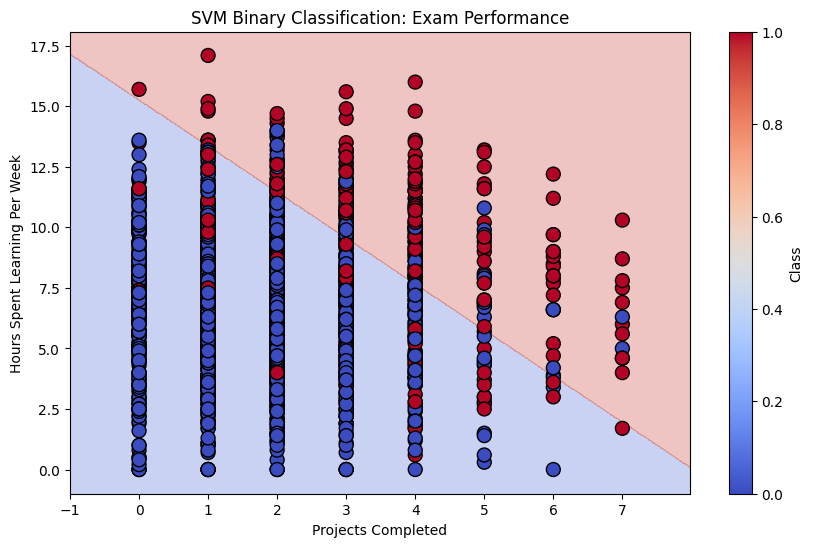

In [131]:
#This graph shows us how SVM separates students who pass and failed.
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')  # Color regions
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolors='k', cmap='coolwarm', s=100)  # Plot data points
plt.xlabel('Projects Completed')
plt.ylabel('Hours Spent Learning Per Week')
plt.title('SVM Binary Classification: Exam Performance')
plt.colorbar(label='Class')
plt.show()

In [132]:
#This graph shows how the SVM creates a linear decision boundary to separate students who pass and fail based on
#hours spent learning per week and projects completed.
# The red points on the graph show the students who have passed and the blue dots
# showing the students who failed.